# This Notebook is used to create a visual representation of the camera trajectories

In [173]:
import numpy as np
import matplotlib.pyplot as plt
import PIL
import json
from PIL import Image
import os

In [174]:
poses=[]
from_ids=[]
to_ids=[]
folder_path = '/home/adam/Desktop/CurrentBranch/src/main/src/vtr_db_extractor/edge_results'
file_count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
print(f"Number of files: {file_count}")
for i in range(0,file_count,1):
    filename = filename=folder_path+f"/edge_{i:04d}.txt"
    matrix = []
    with open(filename, 'r') as file:
        for line in file:
            # Skip empty lines
            if line.startswith('from_vertex_id'):
                # Extract the vertex ID from the line
                from_vertex_id = int(line.split(':')[1].strip())
                # print(f"From Vertex ID: {from_vertex_id}")
                from_ids.append(from_vertex_id)
            elif line.startswith('to_vertex_id'):
                # Extract the vertex ID from the line
                to_vertex_id = int(line.split(':')[1].strip())
                # print(f"To Vertex ID: {to_vertex_id}")
                to_ids.append(to_vertex_id)
            elif line.strip() and not line.startswith('u'):
                # Split the line by whitespace and convert each element to float
                row = [float(val) for val in line.strip().split()]
                matrix.append(row)

    temp = np.array(matrix[0:4])
    poses.append(np.array(matrix[0:4]))
#poses=np.array(poses)

Number of files: 96


In [175]:
for i in range(0,from_ids.__len__(),1):
    print(f"From Vertex ID: {from_ids[i]}, To Vertex ID: {to_ids[i]}")
    print(f"Pose: {poses[i]}")
    print("")

From Vertex ID: 63, To Vertex ID: 64
Pose: [[ 0.999897    0.0113103   0.00882693 -0.711901  ]
 [-0.0114837   0.999737    0.0198487   0.0908425 ]
 [-0.00860011 -0.0199481   0.999764    0.0796804 ]
 [ 0.          0.          0.          1.        ]]

From Vertex ID: 79, To Vertex ID: 80
Pose: [[ 0.997906   -0.0646302   0.00266436 -0.291646  ]
 [ 0.064645    0.997891   -0.00590068  0.0509681 ]
 [-0.00227737  0.00606056  0.999979   -0.0186462 ]
 [ 0.          0.          0.          1.        ]]

From Vertex ID: 15, To Vertex ID: 16
Pose: [[ 0.998826   -0.0480302   0.00637394 -0.112357  ]
 [ 0.0480655   0.998829   -0.0055196  -0.0960303 ]
 [-0.00610137  0.00581949  0.999964    0.0243422 ]
 [ 0.          0.          0.          1.        ]]

From Vertex ID: 47, To Vertex ID: 48
Pose: [[ 0.998353   -0.0571515   0.00490908 -0.135691  ]
 [ 0.0571163   0.998343    0.00703633 -0.0157932 ]
 [-0.00530308 -0.00674435  0.999963   -0.0179794 ]
 [ 0.          0.          0.          1.        ]]

From

In [176]:
def bubble_sort(arr1, arr2, arr3):
    for i in range(len(arr1)):
        # Last i elements are already in place
        for j in range(0, len(arr1) - i - 1):
            if arr1[j] > arr1[j + 1]:
                # Swap if elements are in the wrong order
                arr1[j], arr1[j + 1] = arr1[j + 1], arr1[j]
                arr2[j], arr2[j + 1] = arr2[j + 1], arr2[j]
                arr3[j], arr3[j + 1] = arr3[j + 1], arr3[j]
    return np.array(arr1), np.array(arr2), np.array(arr3)

# Example usage:
my_list = [5, 2, 9, 1, 5, 6]
sorted_from, sorted_to, sorted_poses = bubble_sort(from_ids.copy(), to_ids.copy(), poses.copy())
print("Sorted list:", sorted_from)
print("Corresponding to list:", sorted_to)

Sorted list: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95]
Corresponding to list: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96]


In [177]:
# creating new matrices:
new_poses = []
pose1 = np.array([
    [-1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
new_poses.append(pose1)
for i in range(0,sorted_from.__len__(),1):
    temp_pose = new_poses[i] @ sorted_poses[i]
    new_poses.append(temp_pose)
print(new_poses[0])
new_poses = np.array(new_poses)

[[-1  0  0  0]
 [ 0  1  0  0]
 [ 0  0  1  0]
 [ 0  0  0  1]]


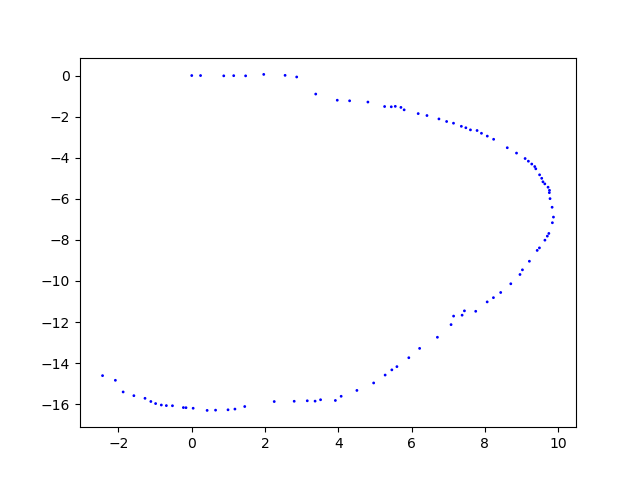

In [178]:
%matplotlib ipympl
origins = new_poses[:, :3, -1]
dirs = np.stack([np.sum([1, 0, 0] * pose[:3, :3], axis=-1) for pose in new_poses])
x= origins[..., 0].flatten()
y= origins[..., 1].flatten()
z= origins[..., 2].flatten()
#print(np.array(x))
# print(type(x))
s = np.ones(len(x))
#plt.scatter(x=x, y=y, color='red')
plt.scatter(x, y, s=s, color='blue', label='Group 1')
plt.show()

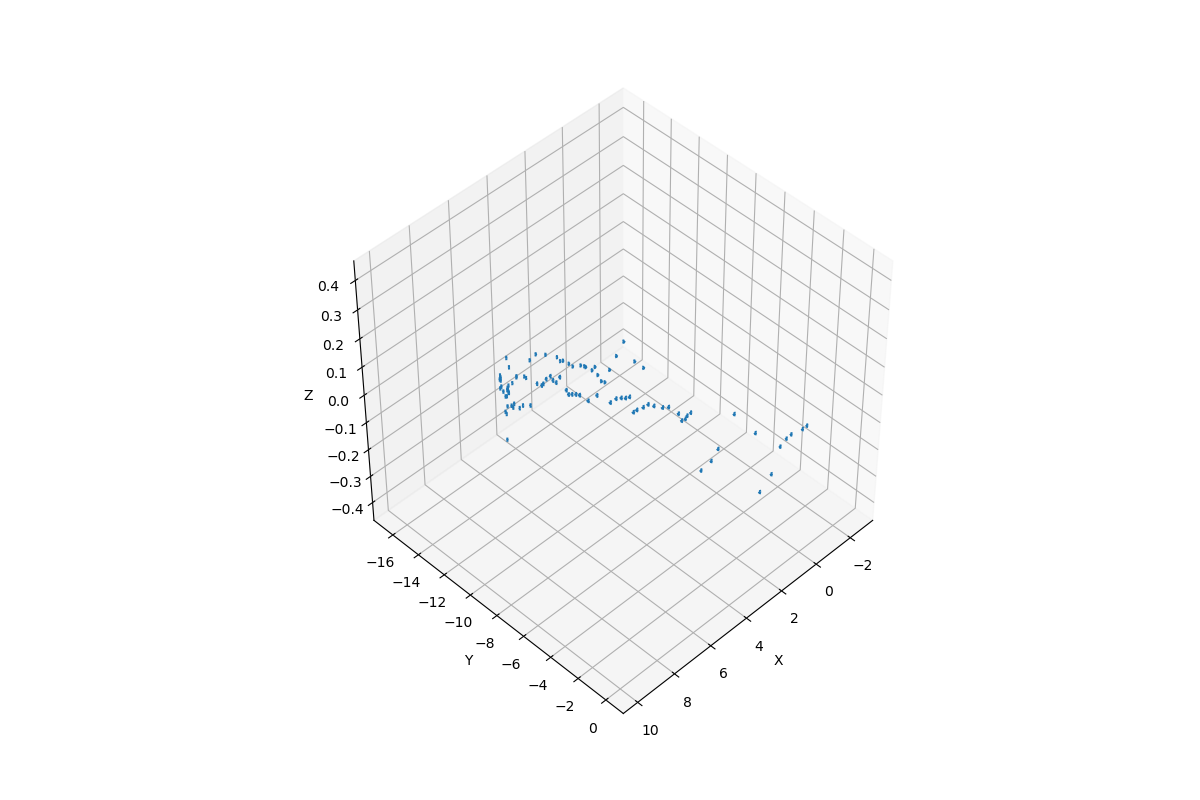

In [181]:
%matplotlib ipympl
# print(origins)
ax = plt.figure(figsize=(12, 8)).add_subplot(projection='3d')
_ = ax.quiver(
  origins[..., 0].flatten(),
  origins[..., 1].flatten(),
  origins[..., 2].flatten(),
  dirs[..., 0].flatten(),
  dirs[..., 1].flatten(),
  dirs[..., 2].flatten(), length=0.1, normalize=True)
ax.set_box_aspect([1,1,1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(45, 45) 
plt.show()

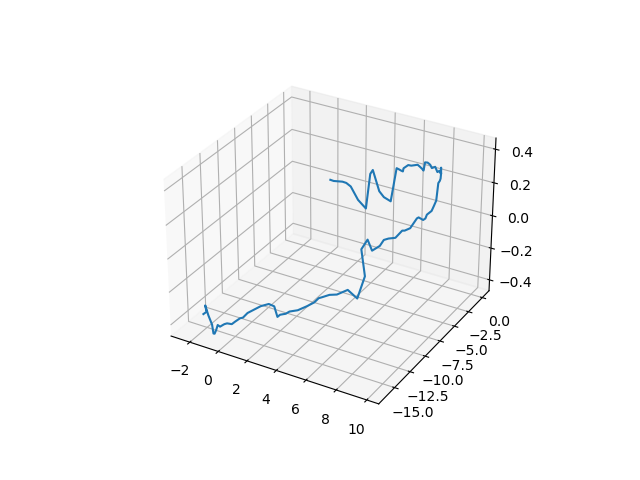

In [182]:
%matplotlib ipympl
ax = plt.axes(projection='3d')
ax.plot3D(x, y, z)